# Libraries and functions

In [1]:
import numpy as np

import sys
from pathlib import Path
import os

import matplotlib.pyplot as plt

# path to the directory that CONTAINS the package folder
project_root = Path("/mnt/beegfs/2a/mb12724/franc/theory-language-modeling/")   # adjust to your real path

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from BP.variational_constrained_bp_last_next_torch import simulate_variational_constrained_bp_sweep

from BP.crossentropy_BP import (
    simulate_crossentropy_bp_trajectory,
    plot_loss_error,
    plot_peeled_loss_and_margin_fraction,
)

/home/2a/mb12724/miniconda3/envs/emb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
# from BP.plot_constrained_bp_results import (
#     load_results,
#     plot_loss_error,
#     plot_budget_diagnostics,
#     plot_hierarchy_observables,
#     plot_loss_decomposition,
#     plot_validity_by_position,
#     plot_peeled_loss_and_margin_fraction,
# )


# Flat rules

In [2]:
name_save = "dynamical_bp_global_L3_s2_v32_m8_v1"

In [3]:

os.makedirs("./data/BP", exist_ok=True)

res = simulate_crossentropy_bp_trajectory(
    prediction_mode="last",
    num_features=32,
    num_classes=32,
    num_synonyms=8,
    tuple_size=2,
    num_layers=3,
    train_size=32768,
    test_size=2048,
    num_steps=2000,
    eval_every=20,
    lr=1e-3,
    init_logit_scale=1e-3,
    bp_consistency_weight=1.0,
)

np.save(f"./data/BP/{name_save}", res, allow_pickle=True)

crossentropy BP (last): 100%|██████████| 2000/2000 [27:14<00:00,  1.22it/s]


In [4]:
res = np.load("./data/BP/"+name_save+".npy", allow_pickle=True).item()

In [5]:
plt.plot(res["kl_to_exact_bp_mean"], label="1")
plt.plot(res["bp_penalty_mean"], label="2")
plt.legend()

KeyError: 'kl_to_exact_bp_mean'

## L=3

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='mean global message-logit norm $\\langle(\\sum_e\\|c_e\\|^2)^{1/2}\\rangle$', ylabel='cross-entropy'>,
        <Axes: title={'center': 'Error'}, xlabel='mean global message-logit norm $\\langle(\\sum_e\\|c_e\\|^2)^{1/2}\\rangle$', ylabel='top-1 error'>],
       dtype=object))

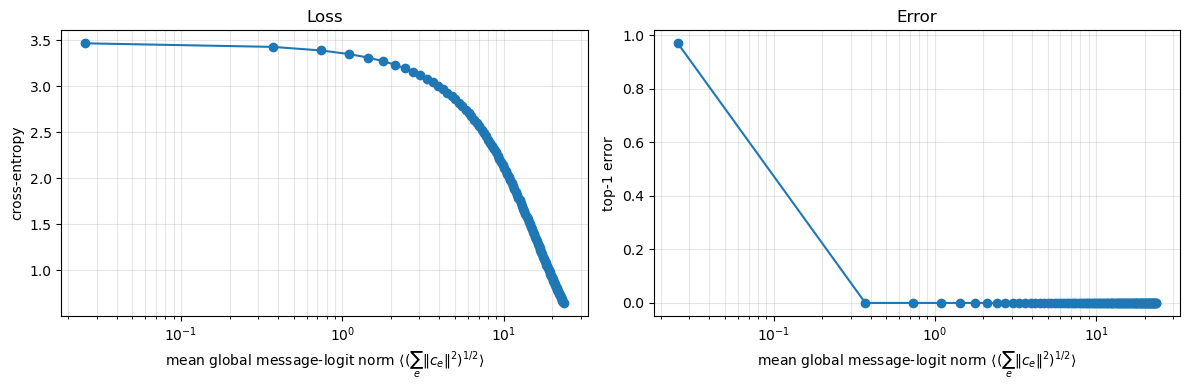

In [7]:
plot_loss_error(res)#, x_key="lambda_values")

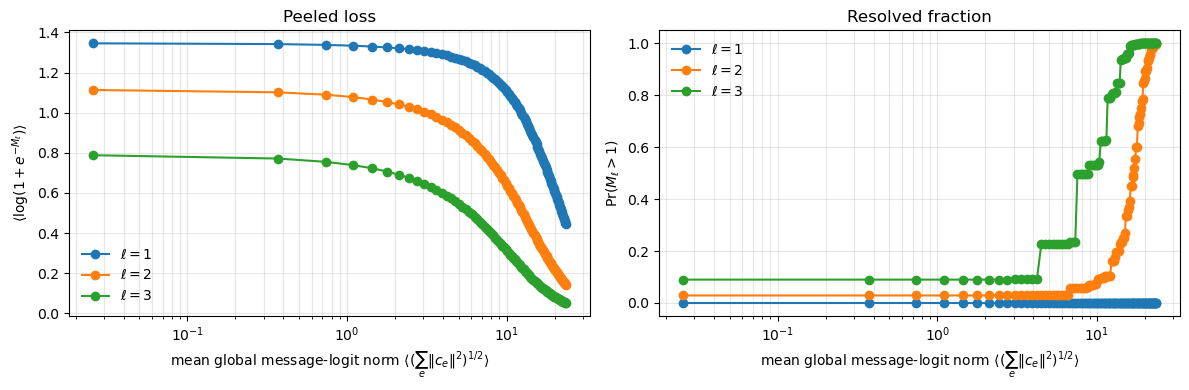

In [10]:
fig, axs = plot_peeled_loss_and_margin_fraction(
    res,
    #x_key="lambda_values",
    #log_y=False
)

## L=4

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Loss'}, xlabel='target message budget $\\lambda$', ylabel='mean test cross-entropy'>,
        <Axes: title={'center': 'Error'}, xlabel='target message budget $\\lambda$', ylabel='mean top-1 error'>],
       dtype=object))

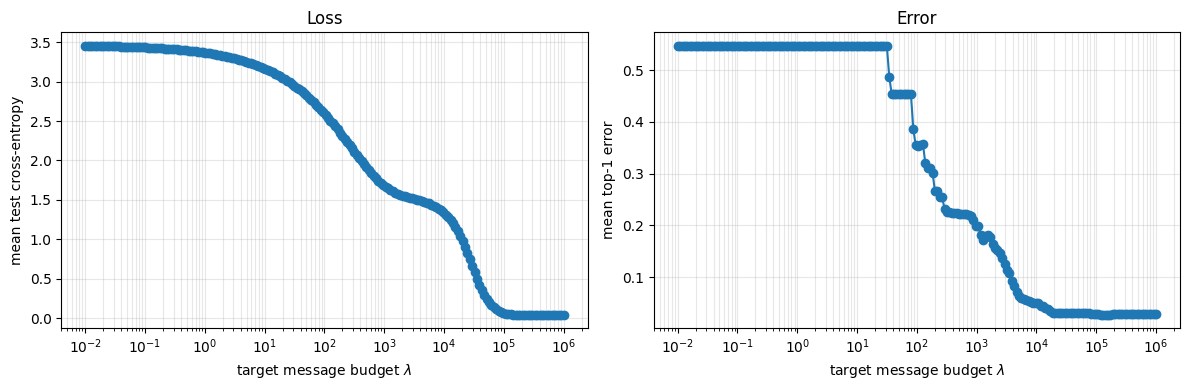

In [29]:
plot_loss_error(res, x_key="lambda_values")

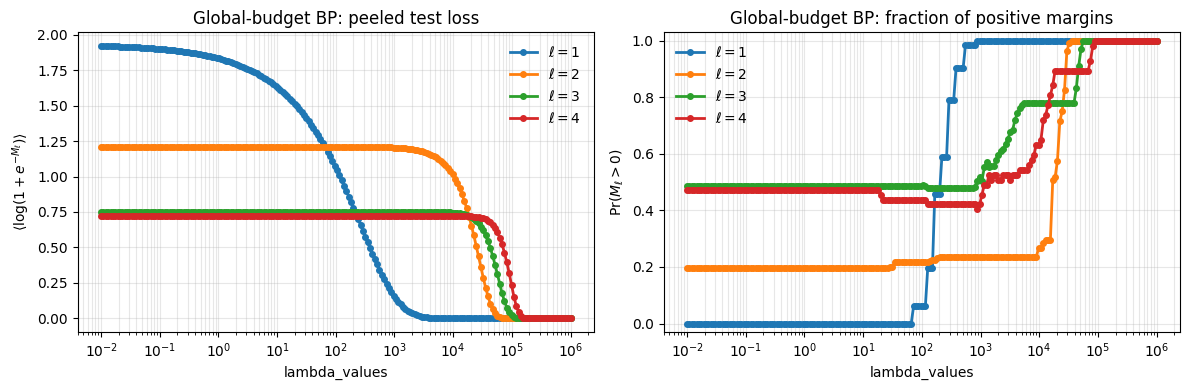

In [30]:
fig, axs = plot_peeled_loss_and_margin_fraction(
    res,
    x_key="lambda_values"
)

# A=2

In [2]:
name_save = "A2_bp_global_budget_L3_s2_v32_m8"

In [3]:

os.makedirs("./data/BP", exist_ok=True)

res = simulate_bp_lambda_sweep(
    num_features=32,
    num_classes=32,
    num_synonyms=8,
    tuple_size=2,
    num_layers=3,
    train_size=32768,
    test_size=128,
    lambda_values=np.logspace(1., 7.0, 20),
    seed_rules=1,
    seed_sample=1,
    zipf=2,   # exponent is 1+zipf
    layer=1,    # exact repo convention: layer index starts at 1
)

np.save(f"./data/BP/{name_save}", res, allow_pickle=True)

100%|██████████| 20/20 [25:48<00:00, 77.42s/it] 


In [4]:
res = np.load("./data/BP/"+name_save+".npy", allow_pickle=True).item()

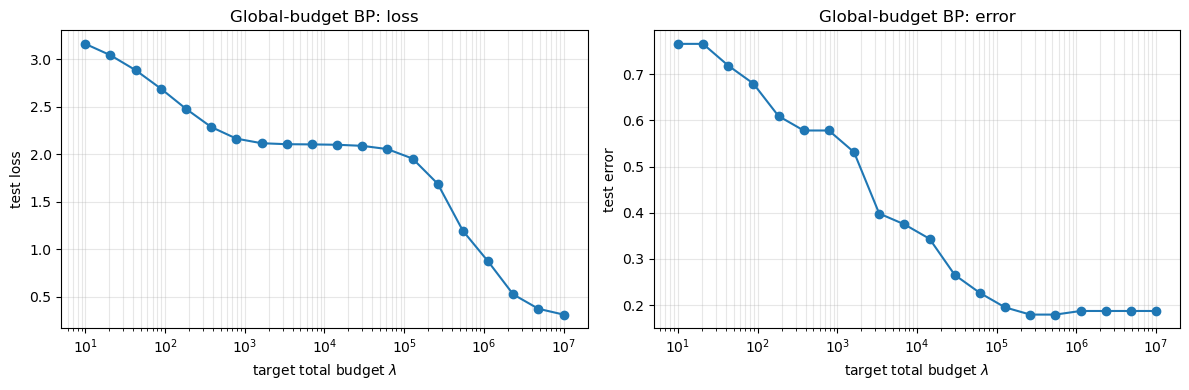

In [5]:
fig, axs = plot_both(res)

In [ ]:
fig2, axs2 = plot_hierarchy_observables(res)